#NLP EXP2

In [ ]:
import nltk # Python Library for NLP
import matplotlib.pyplot as plt # Library for visualization
import random # pseudo-random number generator


In [ ]:
# downLoads sample twitter dataset.
nltk. download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [ ]:
import nltk
from nltk.corpus import twitter_samples


In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
# Load the dataset
tweets = twitter_samples.strings()
type(tweets)

list

In [ ]:
len(tweets)

30000

In [ ]:
import pandas as pd
all_tweets = pd.DataFrame(tweets,columns=["Tweets"])
all_tweets.head()

,Tweets
0,hopeless for tmr :(
1,Everything in the kids section of IKEA is so c...
2,@Hegelbon That heart sliding into the waste ba...
3,"“@ketchBurning: I hate Japanese call him ""bani..."
4,"Dang starting next week I have ""work"" :("


In [ ]:
# Print the length of the first tweet to see its shape
print((Length of the first tweet:" len(tweets[2]))

SyntaxError: unterminated string literal (detected at line 2) (2825833496.py, line 2)

In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
# select the set of positive and negative tweets
positive_tweets = twitter_samples.strings('positive_tweets.json')
negative_tweets = twitter_samples.strings('negative_tweets.json')

In [ ]:
negative_tweets[1]

"Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :("

In [ ]:
positive_tweets[1]

'@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!'

In [ ]:
positive_tweets=pd.DataFrame(positive_tweets,columns=["Tweets"])
positive_tweets["Sentiments"]="positive"

negative_tweets=pd.DataFrame(negative_tweets,columns=["Tweets"])
negative_tweets["Sentiments"]="negative"

In [ ]:
positive_tweets.head()

,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [ ]:
negative_tweets.head()

,Tweets,Sentiments
0,hopeless for tmr :(,negative
1,Everything in the kids section of IKEA is so c...,negative
2,@Hegelbon That heart sliding into the waste ba...,negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",negative
4,"Dang starting next week I have ""work"" :(",negative


In [ ]:
tweets=pd.concat([positive_tweets, negative_tweets], ignore_index=True)
tweets = tweets. sample(frac=1).reset_index(drop=True) #frac=1 => compelete data 100%
tweets

,Tweets,Sentiments
0,@FatalFerret caaaannntttt :(,negative
1,"@Joyster2012 @CathStaincliffe Good for you, gi...",positive
2,everybody fell asleep on me :(,negative
3,@ssxngji good luck for you too! Secret hwaitin...,positive
4,@llymlrs story of my life...!! Love London and...,negative
...,...,...
9995,Thanks @whiskers_cats! Lovely to meet @GailSco...,positive
9996,@graphic_foodie that one at the bottom looks l...,positive
9997,@virtuallykaren cool - thanks for thinking of ...,positive
9998,Bulet gendut :(,negative


In [ ]:
print('Number of positive tweets: ', len(positive_tweets))
print('Number of negative tweets: ', len(negative_tweets))

Number of positive tweets:  5000
Number of negative tweets:  5000


In [ ]:
tweets[tweets["Sentiments"] == "positive"].value_counts().sum()
#tweets[tweets["Sentiments"] == "negative"].value_counts().sum()


np.int64(5000)

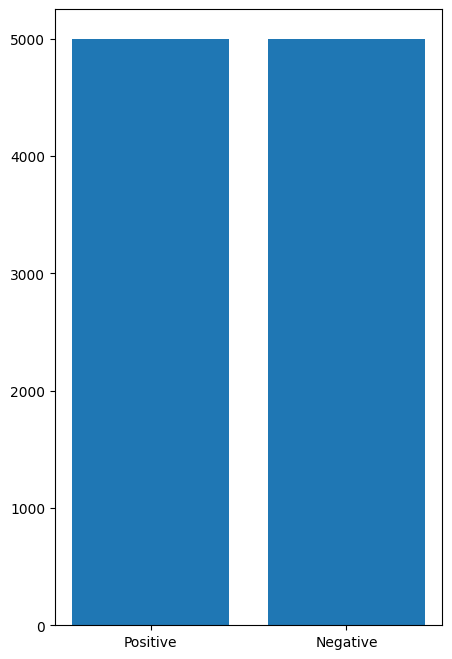

In [ ]:
# Declare a figure with a custom size
fig = plt.figure(figsize=(5, 8)) # 5,5=> x,y ki values == x> to horizontally grapgh & y> toh vertically hoga grpah

# Labels for the two classes
labels = 'Positive', 'Negative'

# Sizes for each slide
sizes = [tweets[tweets["Sentiments"] == "positive"].value_counts().sum(), tweets[tweets["Sentiments"] == "negative"].value_counts().sum()]

# Declare pie chart, where the slices will be ordered and plotted counter-
plt.bar(labels,sizes)

# Display the chart
plt.show()

**Preprocess raw text for Sentiment Analysis**

Data preprocessing is one of the critical steps in any machine leaming project. It includes cleaning and formatting the data before feeding into a machine
learning algorithm. For NLP, the preprocessing steps are comprised of the following tasks:

*   Tokenizing the string
*   Lowercasing
*   Removing stop words and punctuation
*   Stemming





In [ ]:
# Our selected sample. Complex enough to exemplify each step
tweet = positive_tweets. iloc[5]
print(tweet)

Tweets        @BhaktisBanter @PallaviRuhail This one is irre...
Sentiments                                             positive
Name: 5, dtype: object


In [ ]:
# download the stopwords from NLTK
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Library for regular expression oper
import re

# for string operations
import string

# module for stop words that come wit
from nltk.corpus import stopwords

# module for stemming
from nltk.stem import PorterStemmer

# module for tobenizing strings
from nltk.tokenize import TweetTokenizer


In [ ]:
tweet1=tweets["Tweets"] [5059]
tweet1

'@eonnicchi ah thank you, she has a reason to do it right? :)'

In [ ]:
# tweet2=tweets["Tweets"] [6463]
# tweet2

'@casslovesdrake yes cass I think you should :)'

In [ ]:
# remove old style retweet text "RT"
tweet3 = re.sub(r'^RT[\s]+', '', tweet1)


In [ ]:
# remove hyperlinks
tweet3 = re.sub(r'https ?://[^\s\n\r]+', '', tweet3)

In [ ]:
# only removing the hash # sign from the word
tweet3 = re.sub(r'#', '', tweet3)

tweet3 = re.sub(r'[:)|:(]', '', tweet3)

tweet3 = re.sub(r'@','', tweet3)

print(tweet1)
print("\n Cleaned tweet: \n", tweet3)



@eonnicchi ah thank you, she has a reason to do it right? :)

 Cleaned tweet: 
 eonnicchi ah thank you, she has a reason to do it right? 


In [ ]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True) # instantiate tokenizer class

# tokenize tweets
tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('Tokenized string:\n')
print(tweet_tokens)



Tokenized string:

['casslovesdrake', 'yes', 'cass', 'i', 'think', 'you', 'should', ':)']


In [ ]:
#Import the english stop words List from NLTK
stopwords_english = stopwords.words('english')

print('Stop words\n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

Stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s